<a href="https://colab.research.google.com/github/rickphat/EE_Department/blob/main/week4lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install matplotlib numpy

In [32]:

# SimpleGraphics.py
""" A module that supports the simple drawing of colored
rectangles, disks, stars, line segments, and text. """

import matplotlib.pyplot as plt
import numpy as np
from time import sleep as pause

# Built-in SimpleGraphics colors
YELLOW    = [1.0, 1.0, 0.0]
CYAN      = [0.0, 1.0, 1.0]
MAGENTA   = [1.0, 0.0, 1.0]
RED       = [1.0, 0.0, 0.0]
GREEN     = [0.0, 1.0, 0.0]
DARKGREEN     = [0.0, .18, 0.016]
BLUE      = [0.0, 0.0, 1.0]
DARKBLUE= [.02, .04, .2]
LIGHTBLUE = [0.40, 0.70, 1.0]

WHITE     = [1.0, 1.0, 1.0]
BLACK     = [0.0, 0.0, 0.0]
PURPLE    = [0.57, 0.17, 0.93]
DARKGRAY  = [0.33, 0.33, 0.33]
LIGHTGRAY = [0.67, 0.67, 0.67]
ORANGE    = [1.0, 0.50, 0.0]
PINK      = [1.0, 0.71, 0.80]


def MakeWindow(M, labels=True, bgcolor=WHITE):
    """
    Creates a window with x range -M<=x<=M and y range -M<=y<=M
    """
    M = int(M)

    plt.figure(figsize=(8, 8), dpi=80)

    ticks = np.linspace(-M, M, 2 * M + 1)
    plt.xticks(ticks)
    plt.yticks(ticks)

    plt.xlim(-M, M)
    plt.ylim(-M, M)

    axes = plt.gca()
    axes.set_facecolor(bgcolor)  # <-- Fixed here for modern matplotlib

    if not labels:
        axes.set_xticks([])
        axes.set_yticks([])

    axes.set_aspect('equal', adjustable='box')


def ShowWindow(duration=None):
    """
    Display the current window.
    """
    if duration is None:
        plt.show()
    else:
        plt.show(block=False)
        pause(duration)


def CloseWindow():
    """ Close all windows. """
    plt.close('all')


def DrawRect(a, b, L, W, theta=0.0, FillColor=None,
             EdgeColor=BLACK, EdgeWidth=1):

    L = float(L)
    W = float(W)
    theta = np.deg2rad(theta)

    x0 = np.array([-L/2, L/2, L/2, -L/2, -L/2])
    y0 = np.array([-W/2, -W/2, W/2, W/2, -W/2])

    x = a + np.cos(theta) * x0 - np.sin(theta) * y0
    y = b + np.sin(theta) * x0 + np.cos(theta) * y0

    if FillColor is None:
        plt.plot(x, y, color=EdgeColor, linewidth=EdgeWidth)
    else:
        plt.fill(x, y, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)


def DrawDisk(a, b, r, FillColor=None, EdgeColor=BLACK, EdgeWidth=1):

    theta = np.linspace(0, 2 * np.pi, 256)
    x = a + r * np.cos(theta)
    y = b + r * np.sin(theta)

    if FillColor is None:
        plt.plot(x, y, color=EdgeColor, linewidth=EdgeWidth)
    else:
        plt.fill(x, y, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)


def DrawStar(a, b, r, theta=0.0, FillColor=None,
             EdgeColor=BLACK, EdgeWidth=1):

    r2 = r / (2 * (1 + np.sin(np.pi / 10)))
    tau = np.linspace(0, 2 * np.pi, 11) + np.pi / 10 + np.deg2rad(theta)

    x = np.cos(tau)
    y = np.sin(tau)

    x[0::2] *= r
    y[0::2] *= r
    x[1::2] *= r2
    y[1::2] *= r2

    x += a
    y += b

    if FillColor is None:
        plt.plot(x, y, color=EdgeColor, linewidth=EdgeWidth)
    else:
        plt.fill(x, y, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)


def DrawLineSeg(x0, y0, x1, y1, LineColor=BLACK, LineWidth=1):
    plt.plot([x0, x1], [y0, y1],
             color=LineColor, linewidth=LineWidth)


def DrawText(x, y, s, FontColor=BLACK, FontSize=10):
    plt.text(x, y, s, color=FontColor, fontsize=FontSize)


def Title(s, FontColor=BLACK, FontSize=18):
    plt.title(s, fontsize=FontSize, color=FontColor)


def DrawPoly(x, y, FillColor=None, EdgeWidth=1, EdgeColor=BLACK):

    u = list(x) + [x[0]]
    v = list(y) + [y[0]]

    if FillColor is None:
        plt.plot(u, v, linewidth=EdgeWidth, color=EdgeColor)
    else:
        plt.fill(u, v, facecolor=FillColor,
                 edgecolor=EdgeColor, linewidth=EdgeWidth)


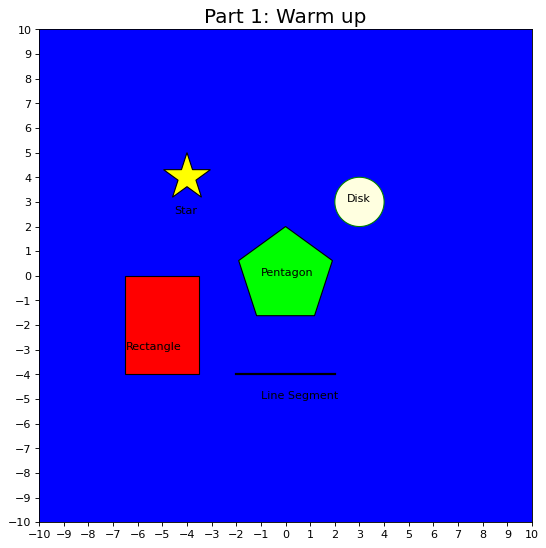

In [11]:
import math

MakeWindow(10, labels=True, bgcolor=BLUE)

# Rectangle
DrawRect(-5, -2, 3, 4, theta=0.0,
         FillColor=RED, EdgeColor=BLACK, EdgeWidth=1)
DrawText(-6.5, -3, "Rectangle", FontColor=BLACK, FontSize=10)

# Disk (Circle)
DrawDisk(3, 3, 1,
         FillColor="LIGHTYELLOW", EdgeColor="GREEN")
DrawText(2.5, 3, "Disk", FontColor=BLACK, FontSize=10)

# Star
DrawStar(-4, 4, 1,
         FillColor="YELLOW", EdgeColor="BLACK")
DrawText(-4.5, 2.5, "Star", FontColor=BLACK, FontSize=10)

# Line Segment
DrawLineSeg(-2, -4, 2, -4, LineColor=BLACK, LineWidth=2)
DrawText(-1, -5, "Line Segment", FontColor=BLACK, FontSize=10)

# Pentagon
px, py = [], []

for k in range(5):
    angle = math.radians(90 + k * 72)
    px.append(2 * math.cos(angle))
    py.append(2 * math.sin(angle))

DrawPoly(px, py, FillColor=GREEN)
DrawText(-1, 0, "Pentagon", FontColor=BLACK, FontSize=10)

# Title
Title("Part 1: Warm up")

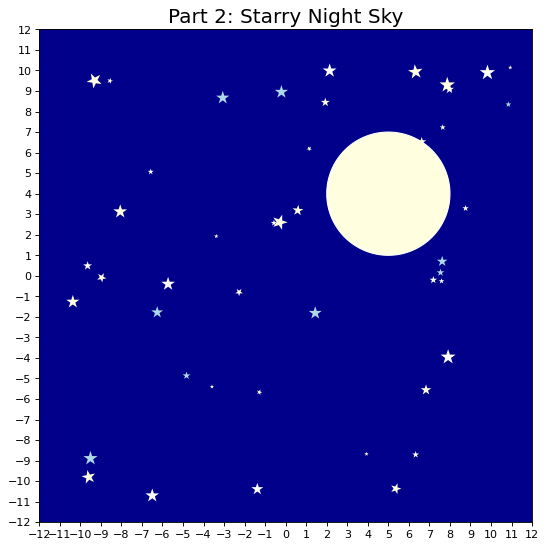

In [21]:

import random

def Code_part2(M):

    # Create dark-blue window
    MakeWindow(M, labels=True, bgcolor="DARKBLUE")

    Title("Part 2: Starry Night Sky")

    # Star colors
    star_colors = ["WHITE", "LIGHTYELLOW", "LIGHTBLUE"]

    # Number of stars
    num_stars = 50

    # Draw random stars
    for _ in range(num_stars):

        # Random position
        x = random.uniform(-M + 1, M - 1)
        y = random.uniform(-M + 1, M - 1)

        # Random size
        r = random.uniform(0.1, 0.4)

        # Random color
        color = random.choice(star_colors)

        # About 20% of stars twinkle
        if random.random() < 0.2:
            theta = random.uniform(0, 360)
            color = "LIGHTYELLOW"
        else:
            theta = 0

        # Draw star
        DrawStar(x, y, r, theta=theta, FillColor=color, EdgeWidth=0)

    # Draw moon LAST so stars don't cover it
    DrawDisk(5, 4, 3,FillColor="LIGHTYELLOW", EdgeColor="WHITE", EdgeWidth=1)

    ShowWindow()


if __name__ == '__main__':
    Code_part2(12)


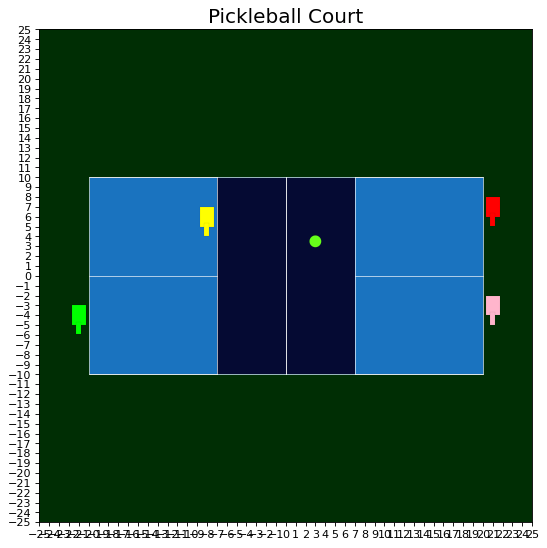

In [63]:


# This scene shows a pickleball court with four paddles and a green pickleball because I enjoy playing pickleball.

def DrawPaddle(x, y, color):
    # Paddle head
    DrawRect(x, y, 1.4, 2.0, FillColor=color, EdgeColor=[0, 0, 0], EdgeWidth=0.05)

    # Paddle handle
    DrawRect(x , y - 1.3, 0.5, 1.3, FillColor=color, EdgeColor=[0, 0, 0], EdgeWidth=0.05)


MakeWindow(25, labels=True, bgcolor=DARKGREEN)
Title("Pickleball Court")

# Main court
DrawRect(0, 0, 40, 20, FillColor=[0.1, 0.45, 0.75], EdgeColor=[1, 1, 1], EdgeWidth=0.52)

# Kitchen
DrawRect(0, 0, 14, 19.9, FillColor=DARKBLUE, EdgeColor=None, EdgeWidth=0.58)


# Court lines using a loop
for x in [-7, 0, 7]:
    DrawLineSeg(x, 10, x, -10, LineColor=[1, 1, 1], LineWidth=0.58)
for y in [-10, 0, 10]:
    DrawLineSeg(7, y, 20, y, LineColor=[1, 1, 1], LineWidth=0.58)
for y in [-10, 0, 10]:
    DrawLineSeg(-7, y, -20, y, LineColor=[1, 1, 1], LineWidth=0.58)


# Center lines
DrawLineSeg(0, -10, 0, 10, LineColor=[1, 1, 1], LineWidth=0.58)




# Four paddles with centered handles
DrawPaddle(-8, 6, YELLOW)
DrawPaddle(21, 7, RED)
DrawPaddle(-21, -4, GREEN)
DrawPaddle(21, -3, PINK)

# Green pickleball
DrawDisk(3, 3.5, 0.6, FillColor=[0.4, 1.0, 0.1], EdgeColor=[0, 0, 0], EdgeWidth=0.05)

ShowWindow()